## Analysis of Articles with "Controvers*" Section Headers

This notebook identifies articles that contain section headers matching "controvers*" (e.g., "Controversy", "Controversial", etc.) in either Wikipedia or Grokipedia, and analyzes their similarity metrics.

In [1]:
import json
import re
from typing import List, Dict, Any, Tuple
from tqdm import tqdm
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Paths
WIKIPEDIA_PATH = "../grokipedia_wikipedia_articles.ndjson"
GROKIPEDIA_PATH = "../grokipedia_scrape.ndjson"
SIMILARITY_STATS_PATH = "../results/overall/similarity/embeddings_similarities_pairwise_stats.parquet"
SIMILARITY_TOP1_PATH = "../results/overall/similarity/embeddings_similarities_pairwise_top1_alignments.parquet"


### Helper Functions


In [3]:
def _norm(s: str) -> str:
    """Normalize string for title matching."""
    return " ".join((s or "").strip().lower().split())

def stream_ndjson(path):
    """Yields objects (dicts) one at a time from an .ndjson file."""
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    yield json.loads(line)
                except Exception:
                    continue

def has_controversy_section_wikipedia(wiki_obj: Dict[str, Any]) -> Tuple[bool, List[str]]:
    """
    Check if Wikipedia article has any section with 'controvers*' in the name.
    Recursively searches through nested sections in has_parts.
    Returns (has_controversy, list_of_matching_section_names)
    """
    if not isinstance(wiki_obj, dict):
        return False, []
    
    sections = wiki_obj.get("sections", [])
    if not isinstance(sections, list):
        return False, []
    
    matching_sections = []
    
    def check_section_recursive(sec: Dict[str, Any]) -> None:
        """Recursively check a section and its nested sections."""
        if not isinstance(sec, dict):
            return
        
        # Check this section's name
        name = (sec.get("name") or "").strip().lower()
        if re.search(r"controvers", name):
            # Store original name (not lowercased)
            matching_sections.append(sec.get("name", ""))
        
        # Recursively check nested sections in has_parts
        has_parts = sec.get("has_parts", [])
        if isinstance(has_parts, list):
            for part in has_parts:
                if isinstance(part, dict) and part.get("type") == "section":
                    check_section_recursive(part)
    
    for sec in sections:
        check_section_recursive(sec)
    
    return len(matching_sections) > 0, matching_sections

def has_controversy_section_grokipedia(g_obj: Dict[str, Any]) -> Tuple[bool, List[str]]:
    """
    Check if Grokipedia article has any section with 'controvers*' in the title.
    Handles both wrapped (data field) and unwrapped structures, similar to preprocessing notebook.
    Note: Grokipedia sections are flat (all at same array level), unlike Wikipedia which has nested sections.
    Returns (has_controversy, list_of_matching_section_titles)
    """
    if not isinstance(g_obj, dict):
        return False, []
    
    # Handle both wrapped and unwrapped data structures (like in 05_preprocessing.ipynb)
    data = g_obj.get("data", g_obj)
    if not isinstance(data, dict):
        return False, []
    
    sections = data.get("sections", [])
    if not isinstance(sections, list):
        return False, []
    
    matching_sections = []
    for sec in sections:
        if not isinstance(sec, dict):
            continue
        title = (sec.get("title") or "").strip().lower()
        if re.search(r"controvers", title):
            # Store original title (not lowercased)
            matching_sections.append(sec.get("title", ""))
    return len(matching_sections) > 0, matching_sections


### Find Articles with Controversy Sections


In [23]:
# Find Wikipedia articles with controversy sections
print("Scanning Wikipedia articles for 'controvers*' sections...")
wiki_controversy_articles = {}
for obj in tqdm(stream_ndjson(WIKIPEDIA_PATH), desc="Wikipedia"):
    title = obj.get("name", "")
    if title:
        has_controversy, sections = has_controversy_section_wikipedia(obj)
        if has_controversy:
            wiki_controversy_articles[_norm(title)] = {
                "title": title,
                "sections": sections,
                "source": "wikipedia"
            }

print(f"Found {len(wiki_controversy_articles)} Wikipedia articles with controversy sections")

with open('../results/controversy_sections/wikipedia.jsonl', 'w') as f:
    for title, info in wiki_controversy_articles.items():
        f.write(json.dumps({"title": title, "sections": info["sections"]}) + "\n")

print('Wrote out to ../results/controversy_sections/wikipedia.jsonl')

Scanning Wikipedia articles for 'controvers*' sections...


Wikipedia: 0it [00:00, ?it/s]

Wikipedia: 964491it [13:22, 1201.66it/s]


Found 18662 Wikipedia articles with controversy sections
Wrote out to ../results/controversy_sections/wikipedia.jsonl


In [6]:
# Find Grokipedia articles with controversy sections
print("Scanning Grokipedia articles for 'controvers*' sections...")
grok_controversy_articles = {}
for obj in tqdm(stream_ndjson(GROKIPEDIA_PATH), desc="Grokipedia"):
    # Handle both wrapped and unwrapped data structures (like in 05_preprocessing.ipynb)
    data = obj.get("data", obj)
    if not isinstance(data, dict):
        continue
    
    # Try main_title first, then title, similar to preprocessing approach
    title = data.get("main_title") or data.get("title") or obj.get("title", "")
    if not title:
        continue
    
    has_controversy, sections = has_controversy_section_grokipedia(obj)
    if has_controversy:
        norm_title = _norm(title)
        grok_controversy_articles[norm_title] = {
            "title": title,
            "sections": sections,
            "source": "grokipedia"
        }

print(f"Found {len(grok_controversy_articles)} Grokipedia articles with controversy sections")

with open('../results/controversy_sections/grokipedia.jsonl', 'w') as f:
    for title, info in grok_controversy_articles.items():
        f.write(json.dumps({"title": title, "sections": info["sections"]}) + "\n")

print('Wrote out to ../results/controversy_sections/grokipedia.jsonl')


Scanning Grokipedia articles for 'controvers*' sections...


Grokipedia: 883858it [11:55, 1234.67it/s]


Found 186828 Grokipedia articles with controversy sections
Wrote out to ../results/controversy_sections/grokipedia.jsonl


In [153]:
print("Scanning Grokipedia articles for 'controvers*' sections...")
grok_controversy_articles = {}
for obj in tqdm(stream_ndjson('../results/v0.2_scrape/scraped_data.jsonl'), desc="Grokipedia"):
    # Handle both wrapped and unwrapped data structures (like in 05_preprocessing.ipynb)
    data = obj.get("data", obj)
    if not isinstance(data, dict):
        continue
    
    # Try main_title first, then title, similar to preprocessing approach
    title = data.get("main_title") or data.get("title") or obj.get("title", "")
    if not title:
        continue
    
    has_controversy, sections = has_controversy_section_grokipedia(obj)
    if has_controversy:
        norm_title = _norm(title)
        grok_controversy_articles[norm_title] = {
            "title": title,
            "sections": sections,
            "source": "grokipedia_v0_2"
        }

print(f"Found {len(grok_controversy_articles)} Grokipedia articles with controversy sections")

with open('../results/controversy_sections/grokipedia_v0_2.jsonl', 'w') as f:
    for title, info in grok_controversy_articles.items():
        f.write(json.dumps({"title": title, "sections": info["sections"]}) + "\n")

print('Wrote out to ../results/controversy_sections/grokipedia_v0_2.jsonl')


Scanning Grokipedia articles for 'controvers*' sections...


Grokipedia: 48307it [03:26, 234.19it/s]


Found 10087 Grokipedia articles with controversy sections
Wrote out to ../results/controversy_sections/grokipedia_v0_2.jsonl


## Textual Analysis: Partisan Valence and Framing

Extract and analyze controversy sections from articles that appear in both Wikipedia and Grokipedia to compare partisan valence and framing differences.


In [8]:
# Merge results - combine Wikipedia and Grokipedia findings
all_controversy_articles = {}
with open('../results/controversy_sections/wikipedia.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        all_controversy_articles[data['title']] = {
            "title": data['title'],
            "sections": data['sections'],
            "source": "wikipedia"
        }

grok_controversy_articles = {}
with open('../results/controversy_sections/grokipedia.jsonl', 'r') as f:
    for line in f:
        data = json.loads(line)
        grok_controversy_articles[data['title']] = {
            "title": data['title'],
            "sections": data['sections'],
            "source": "grokipedia"
        }

for norm_title, info in grok_controversy_articles.items():
    if norm_title in all_controversy_articles:
        # Merge sections and update source
        all_controversy_articles[norm_title]["sections"] = list(set(
            all_controversy_articles[norm_title]["sections"] + info["sections"]
        ))
        if all_controversy_articles[norm_title]["source"] == "wikipedia":
            all_controversy_articles[norm_title]["source"] = "both"
    else:
        all_controversy_articles[norm_title] = info.copy()

print(f"Total unique articles with controversy sections: {len(all_controversy_articles)}")
print(f"  - Wikipedia only: {sum(1 for v in all_controversy_articles.values() if v['source'] == 'wikipedia')}")
print(f"  - Grokipedia only: {sum(1 for v in all_controversy_articles.values() if v['source'] == 'grokipedia')}")
print(f"  - Both: {sum(1 for v in all_controversy_articles.values() if v['source'] == 'both')}")


Total unique articles with controversy sections: 189720
  - Wikipedia only: 2892
  - Grokipedia only: 171058
  - Both: 15770


In [163]:
df2 = pd.read_csv("../supplemental_data/pageview_data/pageviews_1.csv")
# # Assume columns: 'title' and 'pageviews'
# for _, row in df.iterrows():
#     title = row['page_title']
#     views = int(row['noisy_views'])

In [164]:
df = df[df['project'] == 'en.wikipedia'].groupby('page_title')['noisy_views'].sum()
df2 = df2[df2['project'] == 'en.wikipedia'].groupby('page_title')['noisy_views'].sum()


In [182]:
df_join = pd.merge(df, df2, on='page_title', how='outer').fillna(0)
df_join['total_views'] = df_join['noisy_views_x'] + df_join['noisy_views_y']

In [183]:
df_join = df_join.reset_index()
df_join['page_title'] = df_join['page_title'].str.lower()

In [184]:
wikipedia_articles = pd.DataFrame([
    v for v in all_controversy_articles.values()
    if v['source'] == 'wikipedia'
])

In [185]:
wikipedia_articles['page_title'] = wikipedia_articles['title'].str.replace(' ', '_').str.lower()

In [ ]:
wikipedia_articles['page_title'] = wikipedia_articles['title'].str.replace(' ', '_').str.lower()
pd.merge(wikipedia_articles, df_join, on='page_title', how='left').sort_values('total_views', ascending=False)[:50]

,title,sections,source,page_title,noisy_views_x,noisy_views_y,total_views
1812,1xBet,[controversy],wikipedia,1xbet,700447.0,567414.0,1267861.0
2875,XXXTentacion,[controversy_over_snapchat_video_false_accusat...,wikipedia,xxxtentacion,247476.0,302380.0,549856.0
2704,Google,"[criticism_and_controversies, political_contro...",wikipedia,google,249803.0,196145.0,445948.0
2718,Robert F. Kennedy Jr.,[controversy_with_robert_de_niro],wikipedia,robert_f._kennedy_jr.,193419.0,201059.0,394478.0
2285,Facebook,[criticisms_and_controversies],wikipedia,facebook,204271.0,187942.0,392213.0
2596,Nick Fuentes,[legal_issues_and_controversies],wikipedia,nick_fuentes,193985.0,126624.0,320609.0
2497,Nicolás Maduro,[controversies],wikipedia,nicolás_maduro,128498.0,124475.0,252973.0
2126,2025 NFL draft,[prank_call_controversy],wikipedia,2025_nfl_draft,130934.0,87696.0,218630.0
1950,Vietnam War,[us_domestic_controversies],wikipedia,vietnam_war,102952.0,100910.0,203862.0
2205,Nanjing Massacre,[controversy],wikipedia,nanjing_massacre,94193.0,70558.0,164751.0


: 

In [ ]:
import pandas as pd
import os

# Load both CSVs containing the pageviews
pageviews_dir = "../supplemental_data/pageview_data"
pageviews_files = ["pageviews_0.csv", "pageviews_1.csv"]

pageviews = {}
for fname in pageviews_files:
    path = os.path.join(pageviews_dir, fname)
    if os.path.exists(path):
        df = pd.read_csv(path)
        # Assume columns: 'title' and 'pageviews'
        for _, row in df.iterrows():
            title = row['page_title']
            views = int(row['noisy_views'])
            # If duplicate keys, add them together
            if title in pageviews:
                pageviews[title] += views
            else:
                pageviews[title] = views



# If some titles aren't present in pageviews, default to zero
sorted_articles = sorted(
    wikipedia_articles,
    key=lambda v: pageviews.get(v['title'], 0),
    reverse=True
)

for v in sorted_articles:
    print(v['title'])

KeyboardInterrupt: 

In [ ]:
sorted_articles[:50]

In [13]:
def get_object_at_offset(path, offset):
    """Get a JSON object from an NDJSON file at a specific byte offset."""
    with open(path, "r", encoding="utf-8") as f:
        f.seek(offset)
        line = f.readline()
        return json.loads(line)

In [14]:
def extract_controversy_section_text_wikipedia(wiki_obj: Dict[str, Any], section_name: str) -> str:
    """
    Extract full text content from a specific Wikipedia section.
    Recursively searches through nested sections to find the section by name.
    
    Args:
        wiki_obj: Wikipedia article object
        section_name: Name of the section to extract
        
    Returns:
        Full text content of the section, or empty string if not found
    """
    if not isinstance(wiki_obj, dict):
        return ""
    
    sections = wiki_obj.get("sections", [])
    if not isinstance(sections, list):
        return ""
    
    def extract_text_from_section(sec: Dict[str, Any]) -> str:
        """Extract text content from a section's has_parts."""
        has_parts = sec.get("has_parts", [])
        if isinstance(has_parts, list) and has_parts:
            text_parts = []
            
            def extract_from_part(part):
                """Recursively extract text from a part (handles nested sections/lists)"""
                if not isinstance(part, dict):
                    return ""
                part_type = part.get("type", "")
                if part_type == "paragraph":
                    value = part.get("value", "")
                    if value:
                        return value
                elif part_type in ["section", "list"]:
                    nested_parts = part.get("has_parts", [])
                    if isinstance(nested_parts, list):
                        nested_texts = []
                        for nested_part in nested_parts:
                            nested_text = extract_from_part(nested_part)
                            if nested_text:
                                nested_texts.append(nested_text)
                        return " ".join(nested_texts)
                return part.get("value", "") or part.get("text", "")
            
            for part in has_parts:
                part_text = extract_from_part(part)
                if part_text:
                    text_parts.append(part_text)
            
            if text_parts:
                return " ".join(text_parts)
        
        # Fallback: try other possible fields (for compatibility)
        text = sec.get("text", "")
        if text:
            return text
        content = sec.get("content", "")
        if content:
            return content if isinstance(content, str) else str(content)
        paragraphs = sec.get("paragraphs", [])
        if paragraphs:
            return " ".join(str(p) for p in paragraphs if p)
        return ""
    
    def find_section_recursive(sec: Dict[str, Any]) -> str:
        """Recursively search for a section by name."""
        if not isinstance(sec, dict):
            return ""
        
        # Check if this section matches
        if sec.get("name") == section_name:
            return extract_text_from_section(sec)
        
        # Recursively search nested sections in has_parts
        has_parts = sec.get("has_parts", [])
        if isinstance(has_parts, list):
            for part in has_parts:
                if isinstance(part, dict) and part.get("type") == "section":
                    result = find_section_recursive(part)
                    if result:
                        return result
        
        return ""
    
    # Search through all top-level sections recursively
    for sec in sections:
        if not isinstance(sec, dict):
            continue
        result = find_section_recursive(sec)
        if result:
            return result
    
    return ""

def extract_controversy_section_text_grokipedia(g_obj: Dict[str, Any], section_title: str) -> str:
    """
    Extract full text content from a specific Grokipedia section.
    
    Args:
        g_obj: Grokipedia article object
        section_title: Title of the section to extract
        
    Returns:
        Full text content of the section, or empty string if not found
    """
    if not isinstance(g_obj, dict):
        return ""
    
    data = g_obj.get("data", g_obj)
    if not isinstance(data, dict):
        return ""
    
    sections = data.get("sections", [])
    if not isinstance(sections, list):
        return ""
    
    for sec in sections:
        if not isinstance(sec, dict):
            continue
        if sec.get("title") == section_title:
            content = sec.get("content", [])
            if not isinstance(content, list):
                return ""
            
            # Extract text from content items
            text_parts = []
            for item in content:
                if isinstance(item, dict):
                    item_type = item.get("type", "")
                    if item_type == "paragraph":
                        text = item.get("text", "")
                        if text:
                            text_parts.append(text)
                    elif item_type in ["list", "ordered_list"]:
                        items = item.get("items", [])
                        if items:
                            text_parts.extend(str(i) for i in items if i)
            
            return " ".join(text_parts)
    return ""

def extract_all_controversy_sections_text() -> Dict[str, Dict[str, Any]]:
    """
    Extract controversy section text from articles that have sections in both sources.
    Uses cached index files for efficient lookup instead of streaming entire files.
    
    Returns:
        Dictionary mapping title_norm -> {
            'wiki_text': str,
            'grok_text': str,
            'wiki_section_name': str,
            'grok_section_title': str,
            'title': str
        }
    """
    # Filter to articles with "both" sources
    both_articles = {
        norm_title: info 
        for norm_title, info in all_controversy_articles.items() 
        if info['source'] == 'both'
    }
    
    print(f"Extracting text from {len(both_articles)} articles with controversy sections in both sources...")
    
    import pickle
    
    # Load cached indexes
    print("Loading cached indexes...")
    with open('../results/overall/cached_wiki_idx.pkl', 'rb') as f:
        wiki_idx = pickle.load(f)
    with open('../results/overall/cached_grok_idx.pkl', 'rb') as f:
        grok_idx = pickle.load(f)
    
    print(f"  Wikipedia index: {len(wiki_idx)} entries")
    print(f"  Grokipedia index: {len(grok_idx)} entries")
    
    # Extract section texts using cached indexes
    results = {}
    debug_count = 0
    print("Extracting section texts...")
    for norm_title, info in tqdm(both_articles.items(), desc="Extracting"):
        # Look up offsets in cached indexes
        wiki_offset = wiki_idx.get(norm_title)
        grok_offset = grok_idx.get(norm_title)
        
        if wiki_offset is None or grok_offset is None:
            continue
        
        # Retrieve objects using offsets
        # try:
        wiki_obj = get_object_at_offset(WIKIPEDIA_PATH, wiki_offset)
        grok_obj = get_object_at_offset(GROKIPEDIA_PATH, grok_offset)
        # except Exception as e:
        #     # Skip if we can't read the object (file might have changed)
        #     continue
        
        # Use the section names already stored in all_controversy_articles
        # (sections list contains all controversy sections found, merged from both sources)
        all_section_names = info.get("sections", [])
        if not all_section_names:
            continue
        
        # Try to extract text from Wikipedia using any of the stored section names
        wiki_text = ""
        wiki_section_used = ""
        for section_name in all_section_names:
            text = extract_controversy_section_text_wikipedia(wiki_obj, section_name)
            if text:
                wiki_text = text  # Use first non-empty section
                wiki_section_used = section_name
                break
        
        # If no match found, try case-insensitive matching for Wikipedia
        if not wiki_text:
            wiki_sections = wiki_obj.get("sections", [])
            for sec in wiki_sections:
                if isinstance(sec, dict):
                    sec_name = sec.get("name", "")
                    # Check if any stored section name matches (case-insensitive)
                    for stored_name in all_section_names:
                        if sec_name.lower() == stored_name.lower():
                            text = extract_controversy_section_text_wikipedia(wiki_obj, sec_name)
                            if text:
                                wiki_text = text
                                wiki_section_used = sec_name
                                break
                    if wiki_text:
                        break
        
        # Try to extract text from Grokipedia using any of the stored section titles
        grok_text = ""
        grok_section_used = ""
        for section_title in all_section_names:
            text = extract_controversy_section_text_grokipedia(grok_obj, section_title)
            if text:
                grok_text = text  # Use first non-empty section
                grok_section_used = section_title
                break
        
        # If no match found, try case-insensitive matching for Grokipedia
        if not grok_text:
            data = grok_obj.get("data", grok_obj)
            grok_sections = data.get("sections", []) if isinstance(data, dict) else []
            for sec in grok_sections:
                if isinstance(sec, dict):
                    sec_title = sec.get("title", "")
                    # Check if any stored section title matches (case-insensitive)
                    for stored_title in all_section_names:
                        if sec_title.lower() == stored_title.lower():
                            text = extract_controversy_section_text_grokipedia(grok_obj, sec_title)
                            if text:
                                grok_text = text
                                grok_section_used = sec_title
                                break
                    if grok_text:
                        break
        
        if wiki_text and grok_text:
            results[norm_title] = {
                'wiki_text': wiki_text,
                'grok_text': grok_text,
                'wiki_section_name': wiki_section_used,
                'grok_section_title': grok_section_used,
                'title': info['title']
            }
        elif debug_count < 5:
            # Debug first few failures
            print(f"\nDebug {norm_title}:")
            print(f"  Stored sections: {all_section_names}")
            print(f"  Wiki text found: {bool(wiki_text)}")
            print(f"  Grok text found: {bool(grok_text)}")
            if wiki_obj:
                wiki_sec_names = [s.get("name", "") for s in wiki_obj.get("sections", []) if isinstance(s, dict)]
                print(f"  Wiki section names in article: {wiki_sec_names[:5]}")
            if grok_obj:
                data = grok_obj.get("data", grok_obj)
                grok_sec_titles = [s.get("title", "") for s in data.get("sections", []) if isinstance(data, dict) and isinstance(s, dict)]
                print(f"  Grok section titles in article: {grok_sec_titles[:5]}")
            debug_count += 1
    
    print(f"Successfully extracted text from {len(results)} article pairs")
    return results


In [15]:
# Extract controversy section texts
controversy_sections_text = extract_all_controversy_sections_text()
print(f"\nExtracted {len(controversy_sections_text)} article pairs with controversy section text")


Extracting text from 15770 articles with controversy sections in both sources...
Loading cached indexes...
  Wikipedia index: 857392 entries
  Grokipedia index: 880623 entries
Extracting section texts...


Extracting:   1%|          | 158/15770 [00:00<00:47, 325.55it/s]


Debug brit awards 2012:
  Stored sections: ['acceptance_speech_controversy', 'Acceptance speech controversy']
  Wiki text found: True
  Grok text found: False
  Wiki section names in article: ['abstract', 'performances', 'winners_and_nominees', 'multiple_nominations_and_awards', 'acceptance_speech_controversy']
  Grok section titles in article: ['Brit Awards 2012', 'Performances', 'Winners and nominees', 'Outstanding Contribution to Music', 'Multiple nominations and awards']


Extracting:   3%|▎         | 407/15770 [00:01<00:43, 354.70it/s]


Debug ten brothers (2007 tv series):
  Stored sections: ['Controversy of Finale', 'controversy_of_finale']
  Wiki text found: True
  Grok text found: False
  Wiki section names in article: ['abstract', 'synopsis', 'cast', 'controversy_of_finale', 'viewership_ratings']
  Grok section titles in article: ['Ten Brothers (2007 TV series)', 'Ten Brothers', 'Synopsis', 'Cast', 'The Ten Brothers']

Debug lg energy solution:
  Stored sections: ['Controversies', 'controversies']
  Wiki text found: True
  Grok text found: False
  Wiki section names in article: ['abstract', 'history', 'controversies']
  Grok section titles in article: ['LG Energy Solution', 'History of LG Energy Solution', 'History', 'LG Chem Energy Solution Business Division (1992–2020)', 'LG Energy Solution (2020–present)']

Debug millennium wrestling federation:
  Stored sections: ['Controversy', 'controversy']
  Wiki text found: True
  Grok text found: False
  Wiki section names in article: ['abstract', 'history', 'controvers

Extracting:   4%|▎         | 590/15770 [00:01<00:44, 338.49it/s]


Debug sarojini devi eye hospital:
  Stored sections: ['controversy', 'Controversies and Criticisms']
  Wiki text found: False
  Grok text found: True
  Wiki section names in article: ['abstract', 'history', 'controversy']
  Grok section titles in article: ['Sarojini Devi Eye Hospital', 'History', 'Establishment and Founding', 'Key Developments and Milestones', 'Location and Infrastructure']


Extracting:  53%|█████▎    | 8387/15770 [00:32<00:28, 258.30it/s]


KeyboardInterrupt: 

In [30]:
import json
with open('../results/controversy_sections/section_comparison.jsonl', 'w') as f:
    for v in controversy_sections_text.values():
        f.write(json.dumps(v, ensure_ascii=False) + '\n')

In [16]:
import pandas as pd

df = pd.read_json('../results/controversy_sections/section_comparison.jsonl', lines=True)

In [18]:
df = df[
    (~df['title'].str.lower().str.contains('controvers')) # exclude articles with "controversy" in the title
    & (df['grok_section_title'] != df['title']) # AND the relevant section title is not the same as the title
]

### Extract Aligned Chunks (Option C)


In [20]:
from nltk.stem import PorterStemmer
import re

# Initialize stemmer
stemmer = PorterStemmer()

def make_non_gendered(phrase):
    """Remove gender-specific pronouns and make phrases non-gendered."""
    # Replace gender-specific patterns with non-gendered alternatives
    phrase = re.sub(r'\bhe\s+calls\s+himself\s+a\b', r'calls (?:himself|herself|themselves) a', phrase, flags=re.IGNORECASE)
    phrase = re.sub(r'\bhe\s+as\s+much\s+as\b', r'(?:he|she|they) as much as', phrase, flags=re.IGNORECASE)
    phrase = re.sub(r"\bhe's\s+another\b", r"(?:he's|she's|they're) another", phrase, flags=re.IGNORECASE)
    phrase = re.sub(r"\bhe\s+is\s+another\b", r"(?:he's|she's|they're) another", phrase, flags=re.IGNORECASE)

    # Remove standalone pronouns at start
    phrase = re.sub(r'^(?:he|she|they)\s+', '', phrase, flags=re.IGNORECASE)
    return phrase.strip()

def stem_phrase(phrase):
    """Stem all words in a phrase."""
    words = phrase.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

def phrase_to_regex(phrase):
    """Convert a phrase to a regex pattern with word boundaries."""
    # Escape special regex characters
    escaped = re.escape(phrase)
    # Replace escaped spaces with flexible whitespace matching
    escaped = escaped.replace(r'\ ', r'\s+')
    # Add word boundaries
    if ' ' in phrase:
        # Multi-word phrase: match with flexible spacing
        return rf'\b{escaped}\b'
    elif phrase.startswith('-'):
        return rf'\b[a-zA-Z]*{escaped}\b'
    elif phrase.endswith('-'):
        return rf'\b{escaped}[a-zA-Z]*\b'
    else:
        # Single word: strict word boundaries
        return rf'\b{escaped}\b'

# Hyland hedges (https://jolantasinkuniene.wordpress.com/wp-content/uploads/2014/03/hyland-boosting-hedging-and-the-negotiation-of-academic-knowledge-1998.pdf)
hyland_hedges_raw = {
    'about', 'actually', 'admittedly', 'almost', 'always', 'apparent', 'apparently', 
    'appear', 'approximately', 'argue', 'around', 'assume', 'assumption', 'assuredly', 
    'basically', 'believe', 'certain extent', 'certain that', 
    'certainly', 'certainty', 'claim', 'to be clear', 'clear', 'clearly', 'conceivably', 
    'conclude', 'conclusive', 'confirm', 'conjecture', 'consistent with', 'contention', 
    'convincing', 'convincingly', 'could', "couldn't", 'of course', 'course', 'decidedly', 
    'deduce', 'definitely', 'demonstrate', 'determine', 'discern', 'doubt', 'doubtless', 
    'is essential', 'essential', 'essentially', 'establish', 'estimate', 'evidence', 
    'evident', 'evidently', 'expect', 'the fact that', 'the fact', 'we find', 'formally', 
    'frequently', 'general', 'generally', 'given that', 'guess', 'however', 'hypothesize', 
    'hypothetically', 'ideally', 'implication', 'imply', 'impossible', 'improbable', 
    'inconceivable', 'incontrovertible', 'indeed', 'indicate', 'inevitable', 'infer', 
    'interpret', 'we know', 'know', 'it is known', 'known', 'largely', 'least', 'likely', 
    'mainly', 'manifest', 'manifestly', 'may', 'maybe', 'might', 'more or less', 'most', 
    'must', 'necessarily', 'not necessarily', 'never', 'no doubt', 'beyond doubt', 'normally', 
    'obvious', 'obviously', 'occasionally', 'often', 'ostensibly', 'partially', 'partly', 
    'patently', 'perceive', 'perhaps', 'plausible', 'possibility', 'possible', 'possibly', 
    'postulate', 'precisely', 'predict', 'prediction', 'predominantly', 'presumably', 
    'presume', 'probability', 'probable', 'probably', 'propose', 'prove', 'provided that', 
    'open to question', 'question', 'questionable', 'quite', 'rare', 'rarely', 'rather', 
    'relatively', 'reportedly', 'reputedly', 'seems', 'seemingly', 'can be seen', 'seen', 
    'seldom', 'general sense', 'sense', 'should', 'show', 'sometimes', 'somewhat', 
    'speculate', 'suggest', 'superficially', 'suppose', 'sure', 'surely', 'surmise', 
    'suspect', 'technically', 'tend', 'tendency', 'theoretically', 'we think', 'think', 
    'true', 'typically', 'unambiguously', 'unarguably', 'uncertain', 'unclear', 
    'undeniably', 'undoubtedly', 'unequivocal', 'unlikely', 'unmistakably', 
    'unquestionably', 'unsure', 'usually', 'virtually', 'well-known', 'well known', 'will', "won't", 
    'would', "wouldn't", 'wrong', 'wrongly'
}

# Lakoff hedges (https://george-lakoff.com/wp-content/uploads/2011/01/hedges-a-study-in-meaning-criteria-and-the-logic-of-fuzzy-concepts-journal-of-philosophical-logic-2-lakoff-19731.pdf)
lakoff_hedges_raw = {
    'sort of', 'in a real sense', 'kind of', 'in an important sense', 'loosely speaking',
    'in a way', 'more or less', 'mutatis mutandis', 'on the side', 'in a manner of speaking',
    'roughly', 'details aside', 'pretty', 'pretty much', 'so to say', 'relatively',
    'a veritable', 'somewhat', 'a true', 'rather', 'mostly', 'technically', 'strictly speaking',
    'essentially', 'in essence', 'basically', 'principally', 'particularly', 'par excellence',
    'largely', 'for the most part', 'very', 'especially', 'exceptionally', 'a real',
    'a regular', 'virtually', 'all but technically', 'practically', 'all but a',
    'anything but a', 'a self-styled', 'nominally', 'he calls himself a', 'in name only',
    'actually', 'really', 'he as much as', 'can be looked upon as',
    'quintessential', 'quintessentially', 'literally', 'often', 'can be viewed as',
    'more of a than anything else', 'pseudo', 'almost', 'crypto', 'typically', 'typical',
    'as it were', 'in a sense', 'in one sense', "he's another", 'he is another', '-like', '-ish'
}

# Load MPQA Subjectivity Lexicon
def load_mpqa_lexicon(filepath):
    weaksubj_words = set()
    strongsubj_words = set()
    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            
            # Parse the line (format: type=weaksubj len=1 word1=word pos1=adj ...)
            parts = {}
            for item in line.split():
                if '=' in item:
                    key, value = item.split('=', 1)
                    parts[key] = value
            
            # Extract word(s) - handle multi-word phrases
            word_parts = []
            i = 1
            while f'word{i}' in parts:
                word_parts.append(parts[f'word{i}'])
                i += 1
            word = ' '.join(word_parts).lower() if word_parts else ''
            
            if not word:
                continue

            if parts.get('type') == 'weaksubj':
                weaksubj_words.add(word)
            elif parts.get('type') == 'strongsubj':
                strongsubj_words.add(word)
                    
        return weaksubj_words, strongsubj_words


# Process: make non-gendered, then stem, then convert to regex
def process_hedging_words(word_set):
    """Process hedging words: non-gendered -> stemmed -> regex patterns."""
    processed = set()
    for phrase in word_set:
        # Make non-gendered
        non_gendered = make_non_gendered(phrase)
        # Stem
        stemmed = stem_phrase(non_gendered)
        # Convert to regex
        regex_pattern = phrase_to_regex(stemmed)
        processed.add(regex_pattern)
    return processed

modal_verbs = {'should', 'could', 'would', 'might', 'must', 'may', 'can', 'will', 'shall', 'ought'}
modal_verbs_regex = process_hedging_words(modal_verbs)

# Create regex lists
hyland_hedges_regex = process_hedging_words(hyland_hedges_raw)
lakoff_hedges_regex = process_hedging_words(lakoff_hedges_raw)

# Load MPQA lexicon
mpqa_weaksubj_raw, mpqa_strongsubj_raw = load_mpqa_lexicon('../supplemental_data/hedge_words/subjclueslen1-HLTEMNLP05.tff')

# Process: make non-gendered, then stem, then convert to regex
# (using the same process_hedging_words function defined earlier)
mpqa_weaksubj_regex = process_hedging_words(mpqa_weaksubj_raw)
mpqa_strongsubj_regex = process_hedging_words(mpqa_strongsubj_raw)

# all_regex = hyland_hedges_regex | lakoff_hedges_regex #| mpqa_weaksubj_regex | mpqa_strongsubj_regex

# Pre-compile all regex patterns for performance
# This is a huge performance win - compile once, use many times
hyland_hedges_compiled = [re.compile(pattern) for pattern in hyland_hedges_regex]
lakoff_hedges_compiled = [re.compile(pattern) for pattern in lakoff_hedges_regex]
mpqa_weaksubj_compiled = [re.compile(pattern) for pattern in mpqa_weaksubj_regex]
mpqa_strongsubj_compiled = [re.compile(pattern) for pattern in mpqa_strongsubj_regex]
modal_verbs_compiled = [re.compile(pattern) for pattern in modal_verbs_regex]


# from https://en.wikipedia.org/wiki/Wikipedia:Manual_of_Style/Words_to_watch
puffery_raw = {
    'legendary', 'best', 'great', 'greatest', 'acclaimed', 'iconic', 'visionary', 'outstanding', 'leading',
    'celebrated', 'popular', 'award-winning', 'award winning', 'landmark', 'cutting-edge', 'cutting edge',
    'innovative', 'revolutionary', 'extraordinary', 'brilliant', 'hit', 'famous', 'renowned', 'remarkable',
    'prestigious', 'world-class', 'world class', 'respected', 'notable', 'virtuoso', 'honorable', 'awesome',
    'unique', 'pioneering', 'phenomenal', 'prominent'
}

puffery_compiled = [re.compile(pattern) for pattern in process_hedging_words(puffery_raw)]

contentious_raw = {
    'cult', 'racist', 'perverted', 'sexist', 'homophobic', 'transphobic', 'misogynistic', 'sect',
    'fundamentalist', 'heretic', 'extremist', 'denialist', 'terrorist', 'freedom fighter', 'bigot',
    'myth', 'neo-Nazi', 'neo nazi', 'neonazi', '-gate', 'pseudo-', 'controversial'
}

contentious_compiled = [re.compile(pattern) for pattern in process_hedging_words(contentious_raw)]

unsupported_attributions_raw = {
    'some people say', 'many people remember', 'many scholars state', 'it is believed',
    'it is regarded', 'it is considered', 'many are of the opinion', 'most feel', 'experts declare',
    'it is often reported', 'it is widely thought', 'research has shown', 'science says',
    'scientists claim', 'it is often said', 'officially', 'is widely regarded as', 'has been described as'
}

unsupported_attributions_compiled = [re.compile(pattern) for pattern in process_hedging_words(unsupported_attributions_raw)]

doubt_raw = {
    'supposed', 'apparent', 'purported', 'alleged', 'accused', 'so-called', 'so called'
}

doubt_compiled = [re.compile(pattern) for pattern in process_hedging_words(doubt_raw)]

editorializing_raw = {
    'notably', 'it should be noted', 'arguably', 'interestingly', 'essentially', 'utterly', 'actually',
    'only', 'clearly', 'absolutely', 'of course', 'without a doubt', 'indeed', 'happily', 'sadly',
    'tragically', 'aptly', 'fortunately', 'unfortunately', 'untimely'
}

editorializing_compiled = [re.compile(pattern) for pattern in process_hedging_words(editorializing_raw)]

euphemism_raw = {
    'passed away', 'gave their life', 'eternal rest', 'make love', 'challenge', 'an issue with',
    'collateral damage', 'differently abled', 'differently-abled'
}

euphemism_compiled = [re.compile(pattern) for pattern in process_hedging_words(euphemism_raw)]

idioms_raw = {
    "lion's share", "tip of the iceberg", "landslide", "white elephant", "gild the lily",
    "take the plunge", "ace up the sleeve", "bird in the hand", "twist of fate", "at the end of the day"
}

idioms_compiled = [re.compile(pattern) for pattern in process_hedging_words(idioms_raw)]

relative_time_raw = {
    'recently', 'lately', 'currently', 'today', 'presently', 'to date', 'X years ago', 'formerly', 'in the past',
    'traditionally', 'this year', 'this month', 'this winter', 'this spring', 'this summer', 'this fall', 'this autumn',
    'last year', 'last month', 'last winter', 'last spring', 'last summer', 'last fall', 'last autumn',
    'next year', 'next month', 'next winter', 'next spring', 'next summer', 'next fall', 'next autumn',
    'yesterday', 'tomorrow', 'in the future', 'now', 'to this day', 'soon', 'since'
}

relative_time_compiled = [re.compile(pattern) for pattern in process_hedging_words(relative_time_raw)]


In [27]:
def article_length(text: str) -> int:
    """
    Calculates article length as number of words. Returns 0 if input is not valid text.
    """
    if not text or not isinstance(text, str):
        return 0
    return len(text.split())

def analyze_with_lexicons(text: str) -> Dict[str, Any]:
    """
    Apply lexicon-based analysis to text using pre-compiled regex patterns.
    
    Returns:
        Dictionary with sentiment scores, framing word counts, political keyword counts, etc.
    """
    if not text or not isinstance(text, str):
        return {}
    
    # Stem the text once (this is still necessary for matching)
    text_lower = stem_phrase(text.lower())
    
    results = {}

    # Article length (using separate function)
    results['article_length'] = article_length(text)
    
    # Hedging language counts using pre-compiled regex patterns
    # Count matches for each regex pattern set (much faster with pre-compiled patterns)
    hyland_count = sum(1 for pattern in hyland_hedges_compiled if pattern.search(text_lower))
    lakoff_count = sum(1 for pattern in lakoff_hedges_compiled if pattern.search(text_lower))
    mpqa_weaksubj_count = sum(1 for pattern in mpqa_weaksubj_compiled if pattern.search(text_lower))
    mpqa_strongsubj_count = sum(1 for pattern in mpqa_strongsubj_compiled if pattern.search(text_lower))
    
    # Total hedging count (sum of all hedging patterns)
    total_hedging_count = mpqa_weaksubj_count + mpqa_strongsubj_count + hyland_count + lakoff_count
    results['hedging_count'] = total_hedging_count
    results['hedging_ratio'] = total_hedging_count / max(results['article_length'], 1)
    
    # Individual hedging category counts
    results['hedging_hyland'] = hyland_count
    results['hedging_lakoff'] = lakoff_count
    results['hedging_mpqa_weaksubj'] = mpqa_weaksubj_count
    results['hedging_mpqa_strongsubj'] = mpqa_strongsubj_count
    
    # Modal verb count using pre-compiled regex patterns
    modal_count = sum(1 for pattern in modal_verbs_compiled if pattern.search(text_lower))
    results['modal_verb_count'] = modal_count
    results['modal_verb_ratio'] = modal_count / max(results['article_length'], 1)
    
    return results


def analyze_with_mos(text: str) -> Dict[str, Any]:
    """
    Apply lexicon-based analysis to text using pre-compiled regex patterns.
    
    Returns:
        Dictionary with sentiment scores, framing word counts, political keyword counts, etc.
    """
    if not text or not isinstance(text, str):
        return {}
    
    # Stem the text once (this is still necessary for matching)
    text_lower = stem_phrase(text.lower())
    
    results = {}

    # Article length (using separate function)
    results['article_length'] = article_length(text)
    
    # mos words to watch counts using pre-compiled regex patterns
    # Count matches for each regex pattern set (much faster with pre-compiled patterns)
    puffery_count = sum(1 for pattern in puffery_compiled if pattern.search(text_lower))
    contentious_count = sum(1 for pattern in contentious_compiled if pattern.search(text_lower))
    unsupported_attributions_count = sum(1 for pattern in unsupported_attributions_compiled if pattern.search(text_lower))
    doubt_count = sum(1 for pattern in doubt_compiled if pattern.search(text_lower))
    editorializing_count = sum(1 for pattern in editorializing_compiled if pattern.search(text_lower))
    euphemism_count = sum(1 for pattern in euphemism_compiled if pattern.search(text_lower))
    idioms_count = sum(1 for pattern in idioms_compiled if pattern.search(text_lower))
    relative_time_count = sum(1 for pattern in relative_time_compiled if pattern.search(text_lower))
    
    # Total mos words to watch count (sum of all mos words to watch patterns)
    total_mos_count = puffery_count + contentious_count + unsupported_attributions_count + doubt_count + editorializing_count + euphemism_count + idioms_count + relative_time_count
    results['mos_count'] = total_mos_count
    results['mos_ratio'] = total_mos_count / max(results['article_length'], 1)
    
    # Individual hedging category counts
    results['puffery_count'] = puffery_count
    results['contentious_count'] = contentious_count
    results['unsupported_attributions_count'] = unsupported_attributions_count
    results['doubt_count'] = doubt_count
    results['editorializing_count'] = editorializing_count
    results['euphemism_count'] = euphemism_count
    results['idioms_count'] = idioms_count
    results['relative_time_count'] = relative_time_count
    
    return results

In [36]:
from scipy import stats
import numpy as np

def calculate_significance(df_expanded):
    """
    Calculate significance values (p-values) for differences between Wiki and Grok means.
    Uses paired t-tests since these are the same articles from different sources.
    
    Returns:
        DataFrame with statistics for each metric
    """
    # Get all metrics that have both _wiki and _grok versions
    metrics = []
    for col in df_expanded.columns:
        if col.endswith('_wiki'):
            base_name = col.replace('_wiki', '')
            grok_col = f'{base_name}_grok'
            if grok_col in df_expanded.columns:
                metrics.append(base_name)

        if col.endswith('_per_word_wiki'):
            base_name = col.replace('_per_word_wiki', '')
            grok_col = f'{base_name}_per_word_grok'
            if grok_col in df_expanded.columns:
                metrics.append(base_name)
    
    results = []
    
    for metric in metrics:
        wiki_col = f'{metric}_wiki'
        grok_col = f'{metric}_grok'
        
        # Get paired data (remove NaN pairs)
        wiki_data = df_expanded[wiki_col].dropna()
        grok_data = df_expanded[grok_col].dropna()
        
        # Align indices to get paired samples
        common_idx = wiki_data.index.intersection(grok_data.index)
        if len(common_idx) < 2:
            continue
        
        wiki_paired = wiki_data[common_idx]
        grok_paired = grok_data[common_idx]
        
        # Remove any remaining NaN pairs
        valid_mask = ~(wiki_paired.isna() | grok_paired.isna())
        wiki_paired = wiki_paired[valid_mask]
        grok_paired = grok_paired[valid_mask]
        
        if len(wiki_paired) < 2:
            continue
        
        # Calculate means
        wiki_mean = wiki_paired.mean()
        grok_mean = grok_paired.mean()
        mean_diff = grok_mean - wiki_mean
        
        # Paired t-test
        t_stat, p_value = stats.ttest_rel(grok_paired, wiki_paired)
        
        # Calculate effect size (Cohen's d for paired samples)
        differences = grok_paired - wiki_paired
        cohens_d = differences.mean() / differences.std() if differences.std() > 0 else 0
        
        # Calculate 95% confidence interval for the mean difference
        n = len(differences)
        se = differences.std() / np.sqrt(n)
        t_critical = stats.t.ppf(0.975, n - 1)  # 95% CI
        ci_lower = mean_diff - t_critical * se
        ci_upper = mean_diff + t_critical * se
        
        results.append({
            'metric': metric,
            'wiki_mean': wiki_mean,
            'grok_mean': grok_mean,
            'mean_difference': mean_diff,
            'p_value': p_value,
            't_statistic': t_stat,
            'cohens_d': cohens_d,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_pairs': n,
            'significant': p_value < 0.05
        })
    
    results_df = pd.DataFrame(results)
    return results_df

In [37]:
print('analyzing wiki lexicon')
df['wiki_lexicon'] = df['wiki_text'].apply(analyze_with_lexicons)
print('analyzing grok lexicon')
df['grok_lexicon'] = df['grok_text'].apply(analyze_with_lexicons)

print('analyzing wiki lexicon')
df['wiki_length'] = df['wiki_text'].apply(article_length)
print('analyzing grok lexicon')
df['grok_length'] = df['grok_text'].apply(article_length)

# Expand the 'wiki_lexicon' dictionary column into separate columns for each key
wiki_lexicon_df = df['wiki_lexicon'].apply(pd.Series)
grok_lexicon_df = df['grok_lexicon'].apply(pd.Series)
# Add suffixes to distinguish wiki and grok lexicon columns
wiki_lexicon_df = wiki_lexicon_df.add_suffix('_wiki')
grok_lexicon_df = grok_lexicon_df.add_suffix('_grok')
df_expanded = pd.concat([df.reset_index(drop=True), wiki_lexicon_df.reset_index(drop=True), grok_lexicon_df.reset_index(drop=True)], axis=1)

# Calculate ratios for all numeric columns (excluding wiki_length/grok_length themselves)
numeric_cols = df_expanded.select_dtypes(include="number").columns.tolist()
# Remove wiki_length and grok_length themselves from the set to generate ratios for
ratio_cols = [col for col in numeric_cols if col not in ['wiki_length', 'grok_length']]

for col in ratio_cols:
    if 'wiki' in col:
        # Calculate value per word in Wikipedia
        df_expanded[col + '_per_word_wiki'] = df_expanded[col] / df_expanded['wiki_length']
    elif 'grok' in col:
        # Calculate value per word in Grokipedia
        df_expanded[col + '_per_word_grok'] = df_expanded[col] / df_expanded['grok_length']

significance_results = calculate_significance(df_expanded)

# Display results
print("Statistical Significance Tests (Paired t-tests):")
print("=" * 80)
print(significance_results.to_string(index=False))

# Summary of significant differences
print("\n" + "=" * 80)
print("Significant Differences (p < 0.05):")
print("=" * 80)
significant = significance_results[significance_results['significant']]
if len(significant) > 0:
    print(significant[['metric', 'wiki_mean', 'grok_mean', 'mean_difference', 'p_value', 'cohens_d']].to_string(index=False))
else:
    print("No significant differences found at p < 0.05")

analyzing wiki lexicon


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_65550/1076754025.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wiki_lexicon'] = df['wiki_text'].apply(analyze_with_lexicons)


analyzing grok lexicon


KeyboardInterrupt: 

In [ ]:
print('analyzing wiki lexicon')
df['wiki_lexicon'] = df['wiki_text'].apply(analyze_with_mos)
print('analyzing grok lexicon')
df['grok_lexicon'] = df['grok_text'].apply(analyze_with_mos)

print('analyzing wiki lexicon')
df['wiki_length'] = df['wiki_text'].apply(article_length)
print('analyzing grok lexicon')
df['grok_length'] = df['grok_text'].apply(article_length)

# Expand the 'wiki_lexicon' dictionary column into separate columns for each key
wiki_lexicon_df = df['wiki_lexicon'].apply(pd.Series)
grok_lexicon_df = df['grok_lexicon'].apply(pd.Series)
# Add suffixes to distinguish wiki and grok lexicon columns
wiki_lexicon_df = wiki_lexicon_df.add_suffix('_wiki')
grok_lexicon_df = grok_lexicon_df.add_suffix('_grok')
df_expanded = pd.concat([df.reset_index(drop=True), wiki_lexicon_df.reset_index(drop=True), grok_lexicon_df.reset_index(drop=True)], axis=1)

# Calculate ratios for all numeric columns (excluding wiki_length/grok_length themselves)
numeric_cols = df_expanded.select_dtypes(include="number").columns.tolist()
# Remove wiki_length and grok_length themselves from the set to generate ratios for
ratio_cols = [col for col in numeric_cols if col not in ['wiki_length', 'grok_length']]

for col in ratio_cols:
    if 'wiki' in col:
        # Calculate value per word in Wikipedia
        df_expanded[col + '_per_word_wiki'] = df_expanded[col] / df_expanded['wiki_length']
    elif 'grok' in col:
        # Calculate value per word in Grokipedia
        df_expanded[col + '_per_word_grok'] = df_expanded[col] / df_expanded['grok_length']

significance_results = calculate_significance(df_expanded)

# Display results
print("Statistical Significance Tests (Paired t-tests):")
print("=" * 80)
print(significance_results.to_string(index=False))

# Summary of significant differences
print("\n" + "=" * 80)
print("Significant Differences (p < 0.05):")
print("=" * 80)
significant = significance_results[significance_results['significant']]
if len(significant) > 0:
    print(significant[['metric', 'wiki_mean', 'grok_mean', 'mean_difference', 'p_value', 'cohens_d']].to_string(index=False))
else:
    print("No significant differences found at p < 0.05")

analyzing wiki lexicon


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_65550/392718111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wiki_lexicon'] = df['wiki_text'].apply(analyze_with_mos)


analyzing grok lexicon


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_65550/392718111.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grok_lexicon'] = df['grok_text'].apply(analyze_with_mos)


In [83]:
df_controversy = pd.read_parquet('../results/controversy_sections/controversy_aligned_chunks.parquet')

In [ ]:
df_controversy[df_controversy['grok_chunk_ids'].apply(lambda x: len(x) > 1)].sort_values('avg_similarity')[:50][]

,title,wiki_section_header,grok_section_header,wiki_chunk_ids,grok_chunk_ids,wiki_section_text,grok_section_text,avg_similarity,n_wiki_chunks,n_grok_chunks
570,Amber_Rudd,## political_controversies,## Controversies and criticisms,[6],"[123, 148]","at Companies House, I find it difficult to co...","benefits, and pledged adjustments for a more ...",0.357199,1,2
957,AuronPlay,## controversies,## Controversies,[7],"[14, 22, 23]","Spain has described Álvarez as ""the precursor...","57][58]In a June 2019Twittercorrespondence, El...",0.392161,1,3
2937,Elvis_Costello,## public_image_and_controversies,## Controversies and public disputes,[14],"[134, 151, 152]",won a Gemini Award for Best Talk Series. In B...,000 local eye care workers.[138][139]\n\n## Co...,0.397892,1,3
8357,Shilpa_Shetty,## legal_issues_and_controversies,## Controversies and legal challenges,[9],"[71, 93]","that campaign.\n\nIn 2021, edible oils and fo...","a toned physique without rigid extremes, as e...",0.405885,1,2
9255,Three_Cups_of_Tea,## controversy,## Financial and Organizational Controversies,[6],"[81, 154]",of the book was released in 2006 with the sub...,"]In a 2014 interview, Mortenson reiterated tha...",0.420184,1,2
1720,Capital_formation,## controversy,## Controversies and Alternative Views,[7],"[114, 127]",econometrics to estimate the value of the phy...,"and infrastructure, evident in East Asian tak...",0.423802,1,2
2162,Controversies_surrounding_the_Society_of_Saint...,## other_controversies,# Controversies surrounding the Society of Sai...,[8],"[0, 63, 64]",Catholic dioceses and the SSPX within the sta...,# Controversies surrounding the Society of Sai...,0.435355,1,3
3210,Fifteen_to_One,## controversy,## Reception and Controversies,[16],"[79, 88]",displaced from the board with three episodes ...,"episode.[17]McKaig's performance, as a Scotti...",0.439199,1,2
8331,Sharad_Pawar,## controversies,## Controversies and Allegations,[5],"[114, 133, 134]","his public career in 1972, Pawar founded Vidy...",Pawar initiated the Sharad Pawar Inspire Fello...,0.439902,1,3
8329,Sharad_Pawar,## controversies,## Controversies and Allegations,[5],"[114, 133, 134]","his public career in 1972, Pawar founded Vidy...",Pawar initiated the Sharad Pawar Inspire Fello...,0.439902,1,3


In [123]:
df_grokipedia = pd.read_json('../results/controversy_sections/grokipedia.jsonl', lines=True)
df_wiki = pd.read_json('../results/controversy_sections/wikipedia.jsonl', lines=True)

In [124]:
df_grokipedia

,title,sections
0,yamakasi(film),[Controversies]
1,yamal airlines,[Challenges and Controversies]
2,yamal peninsula,[Geological Phenomena and Controversies]
3,yamalo-nenets autonomous okrug,[Controversies]
4,yamal–europe pipeline,[Controversies]
...,...,...
186823,conrad weiser,[Controversies in Indian Policy]
186824,title iv,[Controversies and Resistance]
186825,proud boys,[Controversies and Perspectives]
186826,amreli,[Challenges and Controversies]


In [125]:
df_wiki


,title,sections
0,1116 sen,[controversy]
1,2020 ap exams controversy,"[controversies, previous_controversies, covid-..."
2,1959 south american championship (ecuador),[controversy]
3,2017 big ten football championship game,[college_football_playoff_controversy]
4,a. ayyappan,[metoo_controversy]
...,...,...
18657,metropark station,[renaming_controversy]
18658,miriam margolyes,[controversies]
18659,the 4-skins,[political_positioning_and_controversies]
18660,crime junkie,[gwen_hasselquist_case_coverage_controversy]


In [ ]:
from collections import defaultdict
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

wiki_word_counts = defaultdict(int)
grok_word_counts = defaultdict(int)

import string

for idx, row in df_grokipedia.iterrows():
    for section in row['sections']:
        grok_section_header_split = [s.lower() for s in section.split(' ')]
        for grok_word in grok_section_header_split:
            # Remove punctuation and whitespace from each word
            cleaned_grok_word = grok_word.lower().translate(str.maketrans('', '', string.punctuation + string.whitespace))
            stemmed_grok_word = stem_phrase(cleaned_grok_word)
            if stemmed_grok_word and stemmed_grok_word not in stop_words:
                grok_word_counts[stemmed_grok_word] += 1

for idx, row in df_wiki.iterrows():
    for section in row['sections']:
        wiki_section_header_split = [s.lower() for s in section.split('_')]
        for wiki_word in wiki_section_header_split:
            # Remove punctuation and whitespace from each word
            cleaned_wiki_word = wiki_word.lower().translate(str.maketrans('', '', string.punctuation + string.whitespace))
            stemmed_wiki_word = stem_phrase(cleaned_wiki_word)
            print(stemmed_wiki_word)
            if stemmed_wiki_word and stemmed_wiki_word not in stop_words:
                wiki_word_counts[stemmed_wiki_word] += 1

wiki_word_counts = sorted(wiki_word_counts.items(), key=lambda x: x[1], reverse=True)
grok_word_counts = sorted(grok_word_counts.items(), key=lambda x: x[1], reverse=True)

In [ ]:
grok_v0_2_word_counts = defaultdict(int)

df_grokipedia_v0_2 = pd.read_json('../results/controversy_sections/grokipedia_v0_2.jsonl', lines=True)

for idx, row in df_grokipedia_v0_2.iterrows():
    for section in row['sections']:
        grok_section_header_split = [s.lower() for s in section.split(' ')]
        for grok_word in grok_section_header_split:
            # Remove punctuation and whitespace from each word
            cleaned_grok_word = grok_word.lower().translate(str.maketrans('', '', string.punctuation + string.whitespace))
            stemmed_grok_word = stem_phrase(cleaned_grok_word)
            if stemmed_grok_word and stemmed_grok_word not in stop_words:
                grok_word_counts[stemmed_grok_word] += 1

In [146]:
for (word, count) in wiki_word_counts:
    if 'criti' in word:
        print(word, count)

critic 629
critiqu 5
criticismcontroversi 1


In [152]:
contestations = ['critic', 'debat', 'challeng', 'critiqu', 'disput', 'scrutini', 'scandal', 'misconduct', 'backlash']

grok_sum = 0
wiki_sum = 0
for (word, count) in grok_word_counts:
    if word in contestations:
        grok_sum += count
for (word, count) in wiki_word_counts:
    if word in contestations:
        wiki_sum += count
print(grok_sum / len(df_grokipedia))
print(wiki_sum / len(df_wiki))

0.5172618665296422
0.042332011574322155


In [150]:
wiki_word_counts[20:50]

[('censorship', 42),
 ('campaign', 41),
 ('releas', 40),
 ('award', 39),
 ('nation', 37),
 ('new', 36),
 ('earli', 36),
 ('us', 35),
 ('elect', 35),
 ('histor', 34),
 ('war', 34),
 ('debat', 34),
 ('disput', 32),
 ('2020', 32),
 ('advertis', 32),
 ('scandal', 32),
 ('titl', 30),
 ('histori', 30),
 ('life', 30),
 ('record', 30),
 ('remark', 30),
 ('comment', 29),
 ('misconduct', 29),
 ('ban', 29),
 ('investig', 29),
 ('legaci', 29),
 ('resign', 28),
 ('relat', 28),
 ('origin', 28),
 ('world', 28)]

In [149]:
grok_word_counts[20:50]

[('viewpoint', 2050),
 ('altern', 1942),
 ('surround', 1921),
 ('incid', 1798),
 ('reform', 1671),
 ('modern', 1587),
 ('cultur', 1490),
 ('empir', 1381),
 ('scrutini', 1363),
 ('ethic', 1348),
 ('view', 1314),
 ('intern', 1305),
 ('scholarli', 1299),
 ('respons', 1252),
 ('broader', 1245),
 ('notabl', 1132),
 ('social', 1004),
 ('govern', 991),
 ('regulatori', 964),
 ('societ', 949),
 ('develop', 925),
 ('alleg', 842),
 ('recent', 839),
 ('evalu', 827),
 ('conflict', 807),
 ('backlash', 786),
 ('implic', 784),
 ('event', 780),
 ('involv', 769),
 ('percept', 767)]

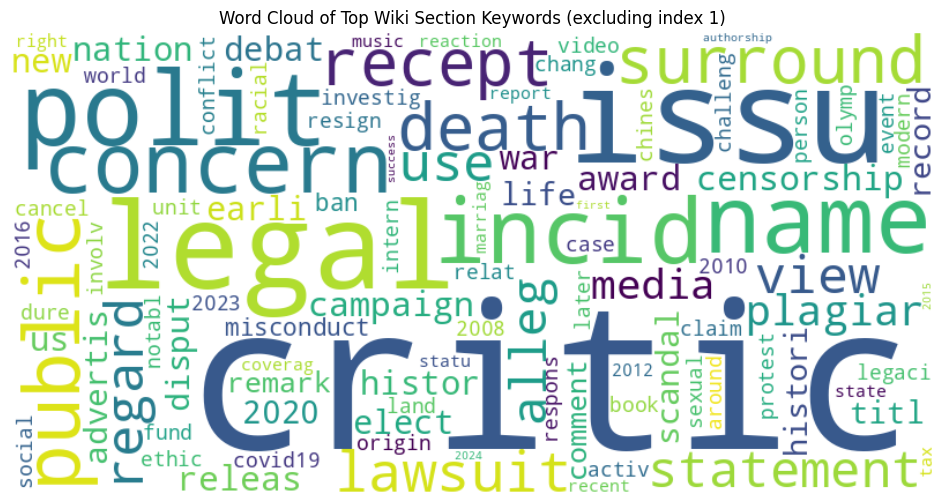

In [144]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Exclude index 1
word_freq_dict = dict(wiki_word_counts[1:101])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top Wiki Section Keywords (excluding index 1)')
plt.show()

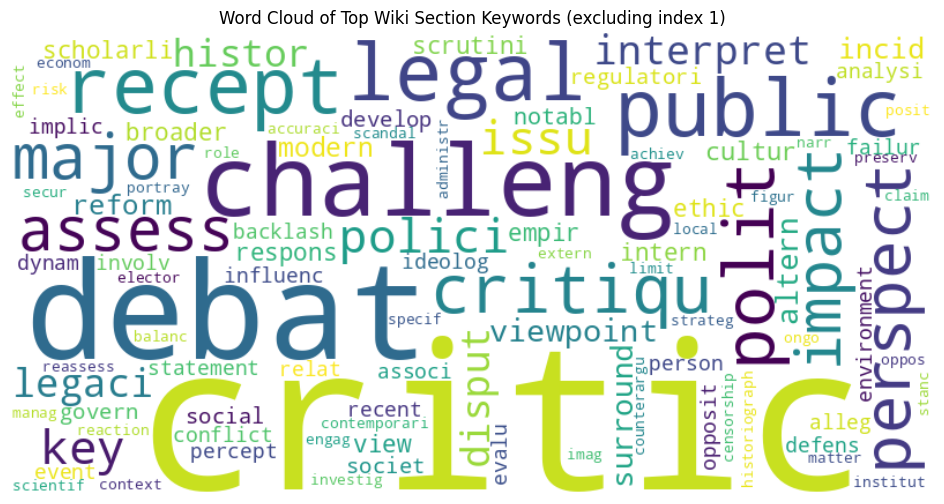

In [145]:
# Exclude index 1
word_freq_dict = dict(grok_word_counts[1:101])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top Wiki Section Keywords (excluding index 1)')
plt.show()

In [90]:
print(df_controversy[['title', 'avg_similarity']].groupby('title').mean().sort_values('avg_similarity', ascending=True)[:50])

                                         avg_similarity
title                                                  
Herbert_Black                                  0.171226
EBay                                           0.172580
PM_Narendra_Modi                               0.209587
National_Institute_of_Rural_Development        0.233905
Great_Ormond_Street_Hospital                   0.235841
Island_Boys                                    0.265672
P._Jayarajan                                   0.266402
Ewha_Womans_University                         0.274196
Smithsonian_Institution                        0.275770
St_Edmund's_College,_Cambridge                 0.277126
Amway_North_America                            0.279242
Wistron                                        0.280427
American_Red_Cross                             0.283267
Denis_Leary                                    0.286609
E._V._Velu                                     0.288736
Habibur_Rahman_(police_officer)                0

In [92]:
titles_of_interest = ['PM_Narendra_Modi', 'Al_Noor_Mosque,_Christchurch', 'Wisconsin_Supreme_Court', 'Amway_North_America', 'Smithsonian_Institution']

for title in titles_of_interest:
    subset = df_controversy[df_controversy['title'] == title]
    print(f"\n{'='*60}\nTitle: {title}\n{'='*60}")
    for idx, row in subset.iterrows():
        print(f"\nWiki section header: {row['wiki_section_header']}")
        print(f"Wiki text:\n{row['wiki_section_text']}\n")
        print(f"Grok section header: {row['grok_section_header']}")
        print(f"Grok text:\n{row['grok_section_text']}\n")


Title: PM_Narendra_Modi

Wiki section header: ## release_and_controversy
Wiki text:
 1947: Earth, starring Aamir Khan, Nandita Das and lyrics by Javed Akhtar used in this film.

Initially, Javed Akhtar and Sameer were unaware about their works from old films being reused in this film. They tweeted they have not written any songs for the film after finding their names on the film' credit row. The film's producer Sandip Ssingh clarified that the credits were given because their songs from previous movies were included.

Music Composer Shashi Suman (Shashi-Khushi Duo) collaborated with music producer Meghdeep Bose on songs "Saugandh Mujhe Iss Mitti Ki", "Hindustani" & "Fakeera".

## release_and_controversy

The film faced significant backlash from several opposition parties, including the Indian National Congress (Commonly known simply as "the Congress"), which described it as a hagiography and argued that its release on 11 April 2019, the opening day of the 2019 Indian general election,

In [91]:
df_controversy[df_controversy['title'] == 'PM_Narendra_Modi']

,title,wiki_section_header,grok_section_header,wiki_chunk_ids,grok_chunk_ids,wiki_section_text,grok_section_text,avg_similarity,n_wiki_chunks,n_grok_chunks
6949,PM_Narendra_Modi,## release_and_controversy,## Controversies and Criticisms,[4],[125],"1947: Earth, starring Aamir Khan, Nandita Das...","008 Mumbai assaults recurring, attributed to f...",0.209587,1,1
